In [63]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [64]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dataset/delivery_data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [65]:
#We rebuild target because notebook must be self-contained.

df["factor"] = (
    df["actual_time"] /
    df["osrm_time"]
)

df["factor"] = (
    df["factor"]
    .replace([np.inf, -np.inf], np.nan)
)

df = df.dropna(subset=["factor"])

In [66]:
edge_df = (
    df.groupby(
        ["source_center", "destination_center"]
    )
    .agg(
        median_factor=("factor", "median"),
        mean_factor=("factor", "mean"),
        corridor_volume=("trip_uuid", "count"),
        median_actual_time=("actual_time", "median"),
        median_osrm_time=("osrm_time", "median"),
        median_distance=("osrm_distance", "median")
    )
    .reset_index()
)

edge_df.shape

(2783, 8)

Buildin the directed Graph

In [67]:
G = nx.DiGraph()

for _, row in edge_df.iterrows():

    G.add_edge(
        row["source_center"],
        row["destination_center"],

        median_factor=row["median_factor"],
        mean_factor=row["mean_factor"],
        corridor_volume=row["corridor_volume"],
        median_actual_time=row["median_actual_time"],
        median_osrm_time=row["median_osrm_time"],
        median_distance=row["median_distance"]
    )

Some netwrok stats

In [68]:
n_nodes = G.number_of_nodes()

n_edges = G.number_of_edges()

density = nx.density(G)

print(f"Nodes: {n_nodes:,}")
print(f"Edges: {n_edges:,}")
print(f"Density: {density:.6f}")

Nodes: 1,657
Edges: 2,783
Density: 0.001014


In [69]:
weak_components = list(
    nx.weakly_connected_components(G)
)

len(weak_components)

64

In [70]:
strong_components = list(
    nx.strongly_connected_components(G)
)

len(strong_components)

545

In [71]:
#largest weak comp
largest_weak = max(
    weak_components,
    key=len
)

print(
    len(largest_weak)
)

1353


HUB DETECTION - Possible outcomes:

Case 1

-Appears Top 5
-Confirmed super-hub.

Case 2

-Appears Top 20
-Major regional hub.

Case 3 - Not visible

-EDA frequency dominance was volume-driven,
-not connectivity-driven.

In [72]:
in_degree_df = pd.DataFrame(
    G.in_degree(),
    columns=["facility", "in_degree"]
)

In [73]:
out_degree_df = pd.DataFrame(
    G.out_degree(),
    columns=["facility", "out_degree"]
)

In [74]:
degree_df = pd.DataFrame(
    G.degree(),
    columns=["facility", "degree"]
)

In [75]:
top_hubs = (
    degree_df
    .sort_values(
        "degree",
        ascending=False
    )
    .head(20)
)

top_hubs

,facility,degree
25,IND000000ACB,94
12,IND562132AAA,71
24,IND160002AAC,61
61,IND421302AAG,58
64,IND501359AAE,57
67,IND712311AAA,46
102,IND110037AAM,45
1,IND411033AAA,43
47,IND131028AAB,40
66,IND600056AAB,36


In [76]:
top_hubs[
    top_hubs["facility"] ==
    "IND000000ACB"
]

,facility,degree
25,IND000000ACB,94


TOP CORRIDORS

In [77]:
top_corridors = (
    edge_df
    .sort_values(
        "corridor_volume",
        ascending=False
    )
    .head(20)
)

In [78]:
top_corridors[
    [
        "source_center",
        "destination_center",
        "corridor_volume",
        "median_factor"
    ]
]

,source_center,destination_center,corridor_volume,median_factor
59,IND000000ACB,IND562132AAA,4976,1.684400
1753,IND562132AAA,IND000000ACB,3316,1.734540
61,IND000000ACB,IND712311AAA,2862,2.026579
57,IND000000ACB,IND501359AAE,1639,1.824324
54,IND000000ACB,IND421302AAG,1617,1.870647
1142,IND421302AAG,IND000000ACB,1269,1.893303
2511,IND781018AAB,IND110037AAM,1137,2.431670
1168,IND421302AAG,IND562132AAA,1131,1.701863
53,IND000000ACB,IND411033AAA,1120,1.757735
60,IND000000ACB,IND600056AAB,1015,1.771784


DELAYED CORRIDORS

In [79]:
delayed_corridors = (
    edge_df[
        edge_df["corridor_volume"] >= 50
    ]
    .sort_values(
        "median_factor",
        ascending=False
    )
)
delayed_corridors.head(20)

,source_center,destination_center,median_factor,mean_factor,corridor_volume,median_actual_time,median_osrm_time,median_distance
488,IND212402AAA,IND211002AAB,31.787879,34.851053,65,1003.0,20.0,29.40720
1139,IND416606AAA,IND416510AAA,26.880918,23.556107,50,1087.0,32.0,34.00260
2739,IND847226AAA,IND842001AAA,9.209877,9.438599,105,680.0,61.0,86.08360
2677,IND829121AAA,IND834002AAB,7.236364,6.671639,57,398.0,54.0,70.52230
2264,IND700136AAG,IND712310AAA,4.611111,4.885273,50,72.0,18.5,22.78195
2684,IND834002AAB,IND827013AAA,4.363636,4.404904,169,222.0,53.0,65.34120
316,IND152026AAA,IND000000ACA,4.300000,3.774656,133,449.0,78.0,105.71150
2559,IND785690AAB,IND785682AAA,4.209375,4.524143,70,108.0,25.0,33.81790
2745,IND851127AAA,IND842001AAA,3.937500,3.852442,80,194.5,59.0,73.77300
159,IND121102AAA,IND121004AAB,3.915517,4.229218,52,92.0,21.0,29.28425


Network Visualization

In [80]:
top_nodes = (
    degree_df
    .sort_values(
        "degree",
        ascending=False
    )
    .head(50)
    ["facility"]
)

In [81]:
H = G.subgraph(top_nodes)

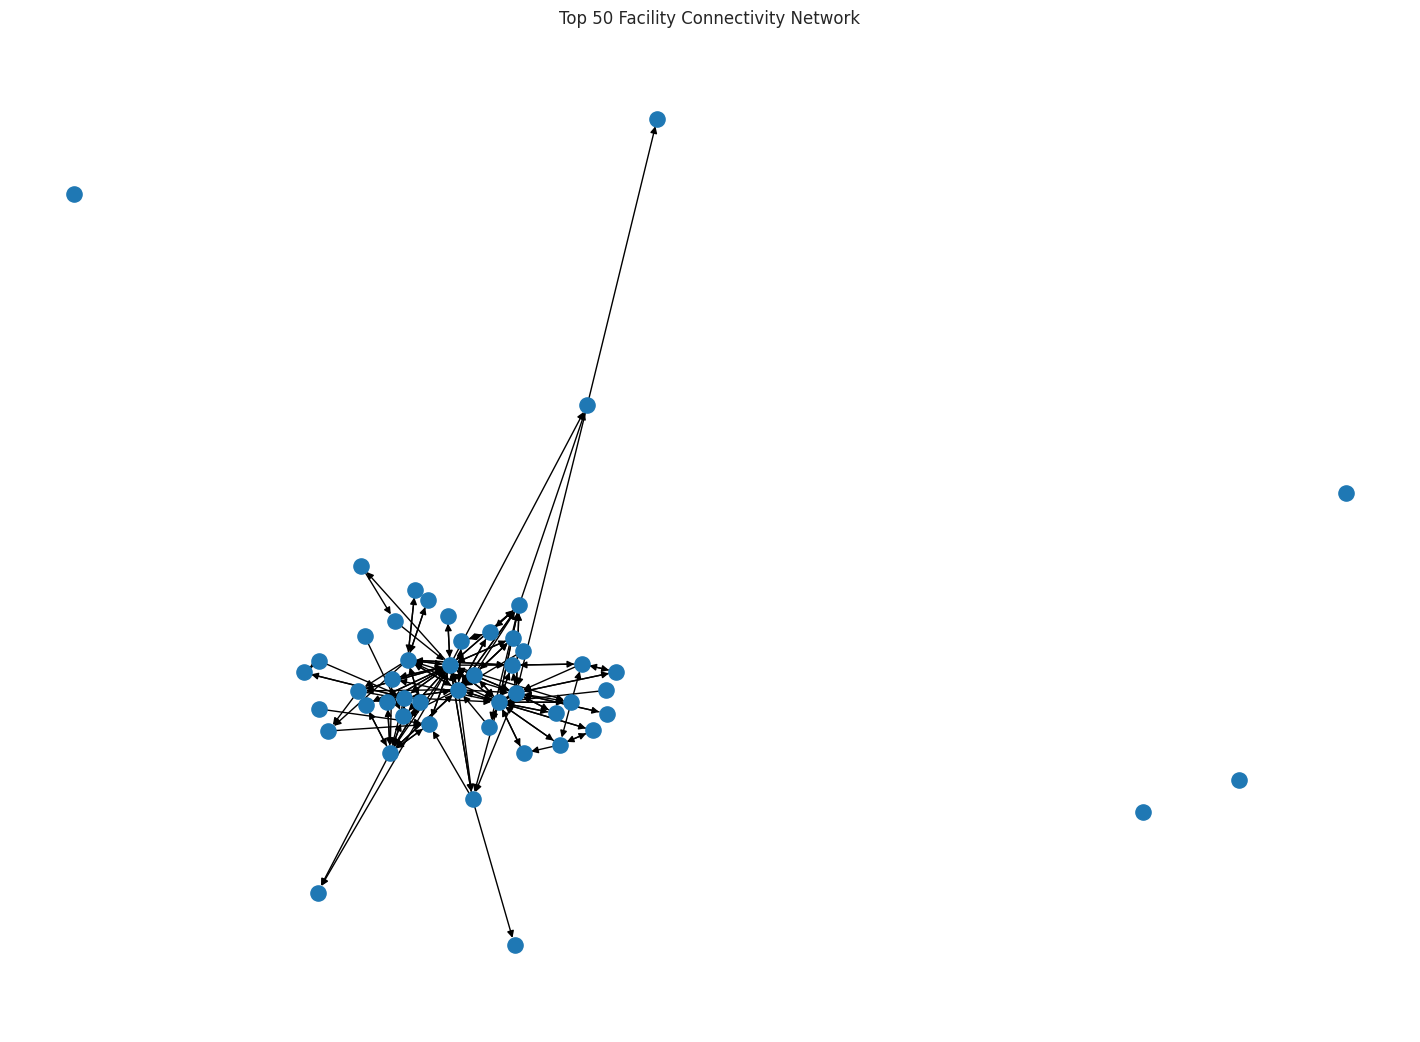

In [82]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    H,
    seed=42
)

nx.draw(
    H,
    pos,
    node_size=120,
    with_labels=False
)

plt.title(
    "Top 50 Facility Connectivity Network"
)

plt.show()

EXPORTS

In [83]:
Path(
    "data/graph_data"
).mkdir(
    parents=True,
    exist_ok=True
)

In [84]:
edge_df.to_csv(
    "data/graph_data/edge_features.csv",
    index=False
)

In [85]:
top_hubs.to_csv(
    "data/graph_data/top_hubs.csv",
    index=False
)

In [86]:
top_corridors.to_csv(
    "data/graph_data/top_corridors.csv",
    index=False
)

GRAPH SUMMARY

In [87]:
summary = pd.DataFrame({
    "nodes":[n_nodes],
    "edges":[n_edges],
    "density":[density],
    "weak_components":[len(weak_components)],
    "strong_components":[len(strong_components)]
})

In [88]:
summary.to_csv(
    "data/graph_data/graph_summary.csv",
    index=False
)

In [89]:
import pickle

with open(
    "data/graph_data/logistics_graph.pkl",
    "wb"
) as f:
    pickle.dump(G, f)

In [90]:
node_df = pd.DataFrame({
    "facility": list(G.nodes())
})

node_df["in_degree"] = node_df["facility"].map(dict(G.in_degree()))
node_df["out_degree"] = node_df["facility"].map(dict(G.out_degree()))
node_df["degree"] = node_df["facility"].map(dict(G.degree()))

node_df.to_csv(
    "data/graph_data/node_features.csv",
    index=False
)

In [91]:
largest_component_pct = (
    len(largest_weak)
    /
    n_nodes
)

print(
    f"{largest_component_pct:.2%}"
)

81.65%
